In [1]:
import pandas as pd

life = pd.read_csv("Life Expectancy Data.csv")

In [2]:
life.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [4]:
life["Status"].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

In [5]:
life.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


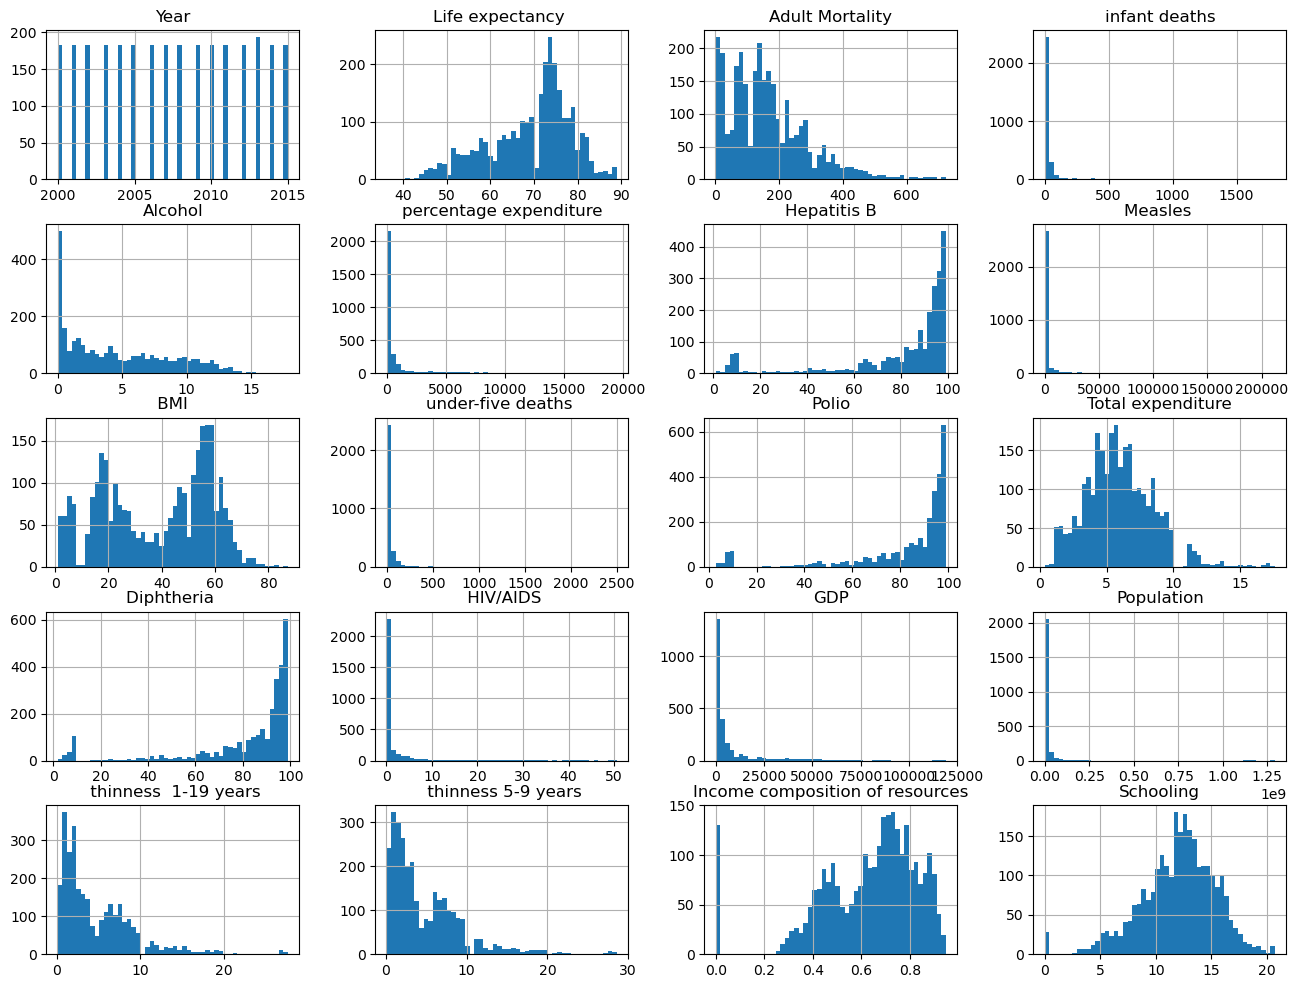

In [6]:
import matplotlib.pyplot as plt

life.hist(bins=50, figsize=(16, 12))
plt.show()

In [7]:
import numpy as np

life.columns = life.columns.str.strip()
life = life.dropna(subset=["Life expectancy"])
life["le_cat"] = pd.cut(life["Life expectancy"], bins=[0., 50.0, 60., 70., 80., np.inf], labels=[1,2,3,4,5])

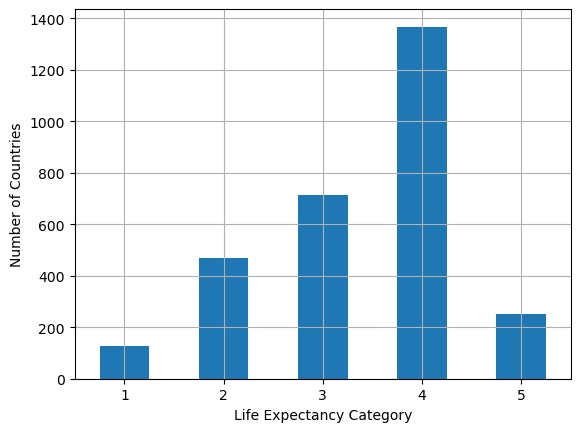

In [8]:
life["le_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Life Expectancy Category")
plt.ylabel("Number of Countries")
plt.show()

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

strat_splits = []
for train_index, test_index in splitter.split(life, life["le_cat"]):
    strat_train_set_n = life.iloc[train_index]
    strat_test_set_n = life.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [10]:
strat_train_set, strat_test_set = strat_splits[0]

In [11]:
strat_test_set["le_cat"].value_counts() / len(strat_test_set)

le_cat
4    0.467577
3    0.244027
2    0.158703
5    0.087031
1    0.042662
Name: count, dtype: float64

In [12]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("le_cat", axis=1, inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_15728\1086102655.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("le_cat", axis=1, inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_15728\1086102655.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("le_cat", axis=1, inplace=True)


In [13]:
life = strat_train_set.copy()

<Axes: xlabel='Year'>

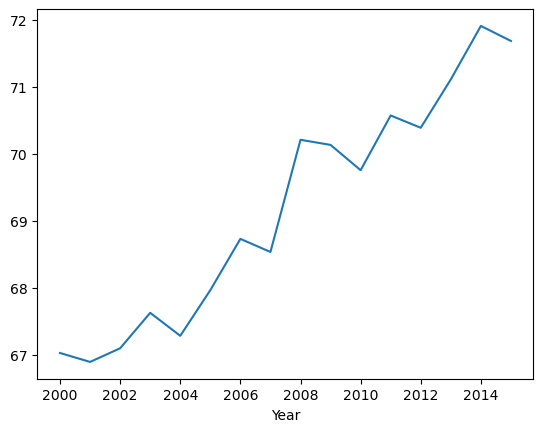

In [14]:
life.groupby("Year")["Life expectancy"].mean().plot()

In [15]:
corr_matrix = life.corr(numeric_only=True)

In [16]:
corr_matrix["Life expectancy"].sort_values(ascending=False)

Life expectancy                    1.000000
Schooling                          0.756959
Income composition of resources    0.734580
BMI                                0.569850
Diphtheria                         0.487489
Polio                              0.468741
GDP                                0.453074
Alcohol                            0.404099
percentage expenditure             0.378102
Hepatitis B                        0.254933
Total expenditure                  0.213595
Year                               0.171219
Population                        -0.027603
Measles                           -0.154206
infant deaths                     -0.208086
under-five deaths                 -0.237625
thinness 5-9 years                -0.462226
thinness  1-19 years              -0.465813
HIV/AIDS                          -0.560492
Adult Mortality                   -0.689018
Name: Life expectancy, dtype: float64

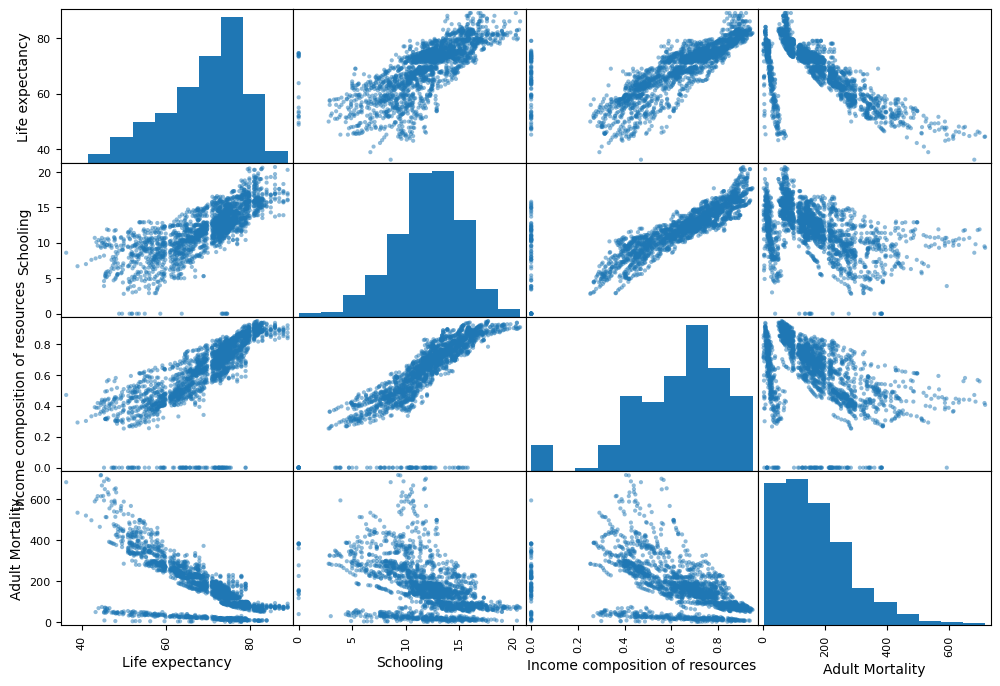

In [17]:
from pandas.plotting import scatter_matrix

attributes = ["Life expectancy", "Schooling", "Income composition of resources", "Adult Mortality"]
scatter_matrix(life[attributes], figsize=(12, 8))
plt.show()

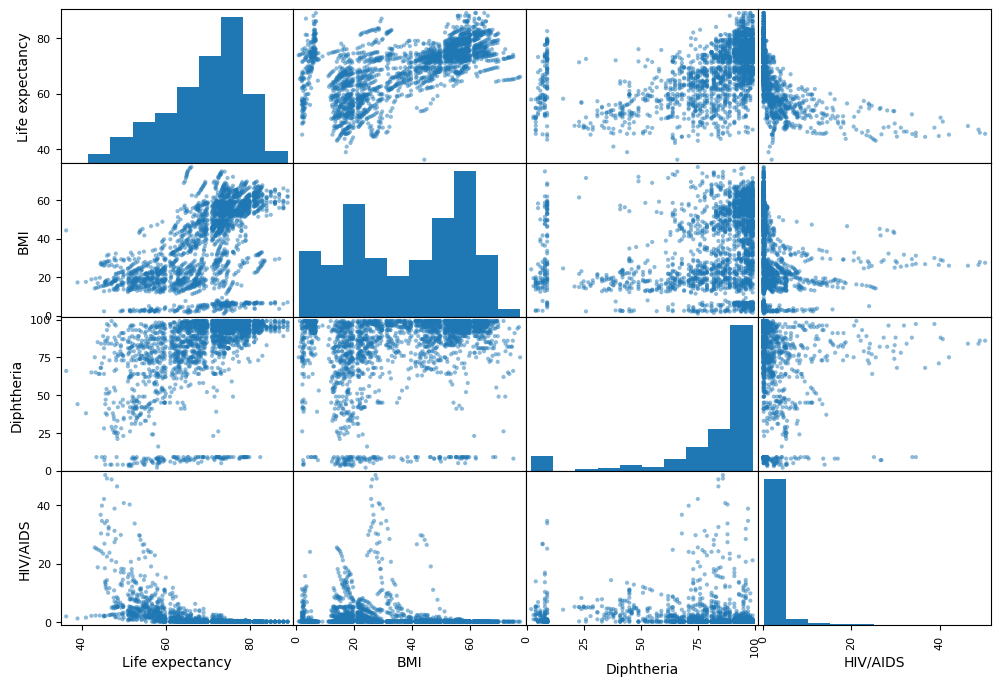

In [18]:
attributes2 = ["Life expectancy", "BMI", "Diphtheria", "HIV/AIDS"]
scatter_matrix(life[attributes2], figsize=(12, 8))
plt.show()

In [19]:
life["child_mortality_ratio"] = life["infant deaths"] / (life["under-five deaths"] + 1)
life["mortality_burden"] = (
    life["Adult Mortality"] +
    life["HIV/AIDS"]
)
life["edu_income_interaction"] = life["Schooling"] * life["Income composition of resources"]
life["vaccination_index"] = (life["Polio"] + life["Diphtheria"] + life["Hepatitis B"]) / 3
life["health_efficiency"] = life["percentage expenditure"] / (life["GDP"] + 1)
life["nutrition_gap"] = life["BMI"] - life["thinness  1-19 years"]

In [20]:
corr_matrix = life.corr(numeric_only=True)
corr_matrix["Life expectancy"].sort_values(ascending=False)

Life expectancy                    1.000000
edu_income_interaction             0.790709
Schooling                          0.756959
Income composition of resources    0.734580
nutrition_gap                      0.594233
BMI                                0.569850
Diphtheria                         0.487489
Polio                              0.468741
GDP                                0.453074
Alcohol                            0.404099
vaccination_index                  0.382172
percentage expenditure             0.378102
Hepatitis B                        0.254933
Total expenditure                  0.213595
health_efficiency                  0.194916
Year                               0.171219
Population                        -0.027603
Measles                           -0.154206
infant deaths                     -0.208086
under-five deaths                 -0.237625
child_mortality_ratio             -0.375881
thinness 5-9 years                -0.462226
thinness  1-19 years            

In [21]:
life = strat_train_set.drop("Life expectancy", axis=1)
life_labels = strat_train_set["Life expectancy"].copy()

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [23]:
life_num = life.select_dtypes(include=[np.number])
imputer.fit(life_num)

SimpleImputer(strategy='median')

In [24]:
imputer.statistics_

array([2.00800000e+03, 1.44000000e+02, 3.00000000e+00, 3.64500000e+00,
       6.40593521e+01, 9.20000000e+01, 1.70000000e+01, 4.31000000e+01,
       4.00000000e+00, 9.30000000e+01, 5.76000000e+00, 9.30000000e+01,
       1.00000000e-01, 1.79016586e+03, 1.33451500e+06, 3.30000000e+00,
       3.40000000e+00, 6.77000000e-01, 1.23000000e+01])

In [25]:
life_num.median().values

array([2.00800000e+03, 1.44000000e+02, 3.00000000e+00, 3.64500000e+00,
       6.40593521e+01, 9.20000000e+01, 1.70000000e+01, 4.31000000e+01,
       4.00000000e+00, 9.30000000e+01, 5.76000000e+00, 9.30000000e+01,
       1.00000000e-01, 1.79016586e+03, 1.33451500e+06, 3.30000000e+00,
       3.40000000e+00, 6.77000000e-01, 1.23000000e+01])

In [26]:
X = imputer.transform(life_num)

In [27]:
life_cat = life[["Status"]]
life_cat.head(8)

,Status
364,Developing
1973,Developing
357,Developing
948,Developing
165,Developing
655,Developed
395,Developed
83,Developing


In [28]:
life["Status"] = life["Status"].map({"Developed": 1, "Developing": 0})

In [29]:
life["Status"].head(8)

364     0
1973    0
357     0
948     0
165     0
655     1
395     1
83      0
Name: Status, dtype: int64

In [30]:
life = life.drop("Country", axis=1)

In [31]:
life

,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
364,2003,0,172.0,88,6.95,15.857812,97.0,2,46.1,100,99.0,6.94,99.0,0.1,359.587582,182482149.0,3.3,3.3,0.699,14.8
1973,2001,0,124.0,2,5.43,7.320514,98.0,0,46.9,2,95.0,7.72,99.0,0.1,446.372833,389684.0,2.3,2.3,0.721,12.4
357,2010,0,154.0,54,7.52,1111.191325,96.0,68,52.0,61,99.0,8.27,99.0,0.1,11224.154800,196796269.0,2.9,2.9,0.716,13.8
948,2013,0,255.0,2,8.86,154.875888,79.0,122,35.2,3,77.0,3.98,79.0,3.7,9679.742995,1817271.0,6.2,6.1,0.678,12.5
165,2010,0,161.0,0,9.19,0.000000,98.0,0,61.3,0,97.0,7.44,99.0,0.2,NaN,NaN,2.5,2.5,0.788,12.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1834,2010,1,64.0,1,9.33,1035.621437,NaN,15,59.3,1,97.0,1.48,97.0,0.1,5338.254830,16615394.0,1.0,0.9,0.906,17.0
2072,2014,0,69.0,0,1.15,5063.513104,89.0,46,68.4,0,99.0,2.19,89.0,0.1,86852.711900,NaN,5.2,4.8,0.854,13.4
2156,2010,0,26.0,16,7.92,63.787236,97.0,121,18.3,23,93.0,7.91,97.0,2.3,563.491487,1246842.0,6.5,6.3,0.454,10.0
1205,2012,0,183.0,129,0.08,254.468826,83.0,15489,24.7,154,84.0,2.90,83.0,0.3,3687.953996,248883232.0,1.5,1.4,0.669,12.6


In [32]:
life.columns

Index(['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol',
       'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI',
       'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

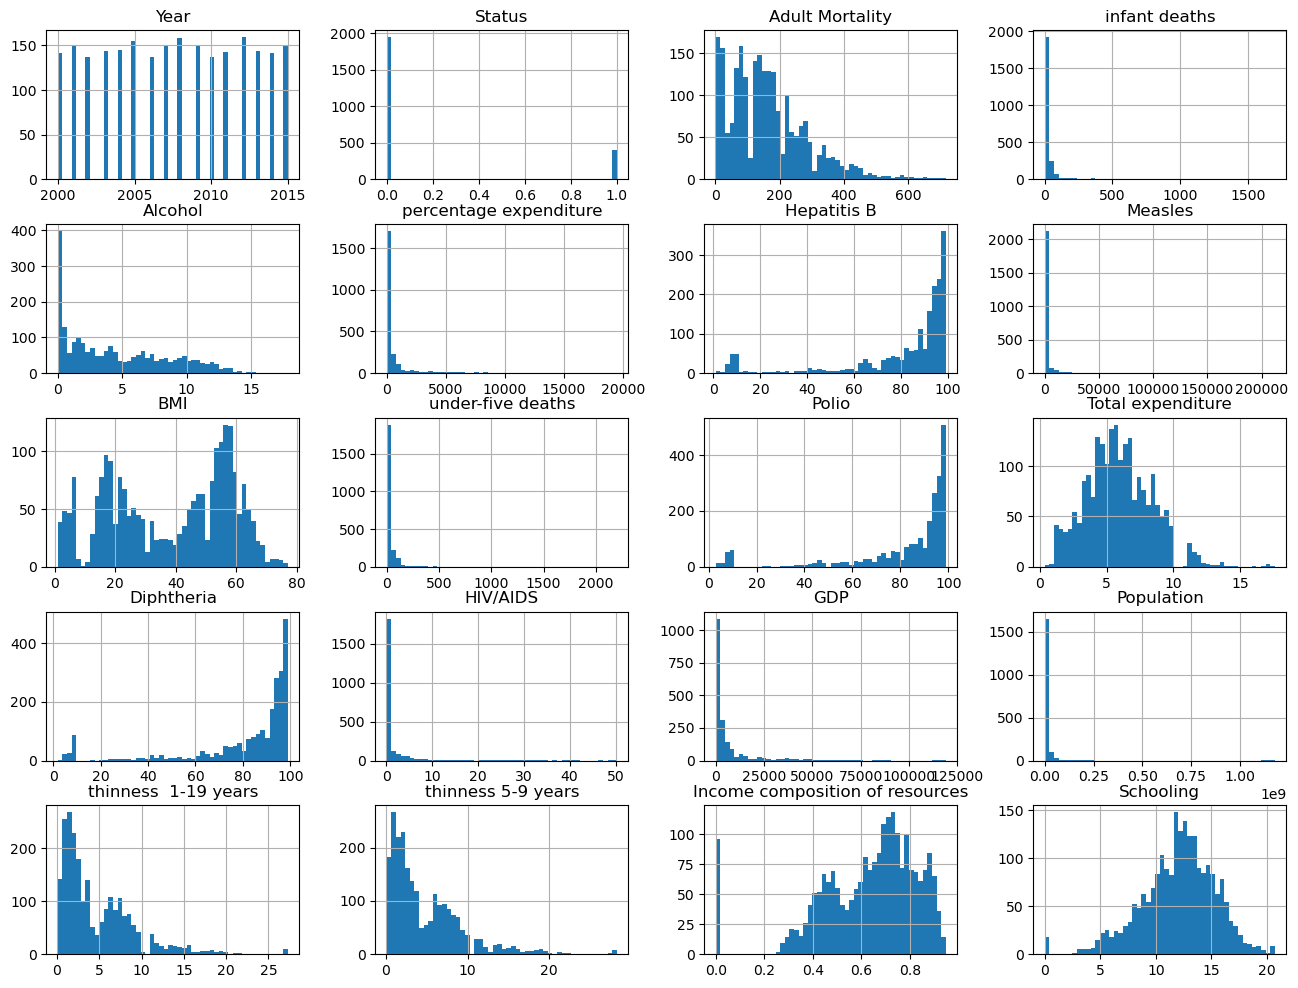

In [33]:
life.hist(bins=50, figsize=(16, 12))
plt.show()

In [34]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

status_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encode", FunctionTransformer(
        lambda x: (x == "Developed").astype(int),
        feature_names_out="one-to-one"
    ))
])

log_features = [
    "GDP",
    "Population",
    "HIV/AIDS",
    "Measles",
    "under-five deaths",
    "infant deaths",
    "percentage expenditure"
]

preprocessing = ColumnTransformer([
    ("log", log_pipeline, log_features),
    ("status", status_pipeline, ["Status"])
],
remainder=num_pipeline)

In [35]:
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("model", LinearRegression())
])

In [36]:
X_train = strat_train_set.drop(["Life expectancy", "Country"], axis=1)
y_train = strat_train_set["Life expectancy"]

X_test = strat_test_set.drop(["Life expectancy", "Country"], axis=1)
y_test = strat_test_set["Life expectancy"]

In [37]:
lin_reg.fit(X_train, y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('scaler',
                                                              StandardScaler())]),
                                   transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('standardscal...
                                                                   StandardScaler())]),
                                                  ['GDP', 'Population',
                                                   'HIV/AIDS', 'Measles',
                                                   'under-five deaths',
                                                   'infant deaths',
                                                   'percentage expenditure']),
                                                 ('status',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function <lambda> at 0x0000023454E4C0E0>))]),
                                                  ['Status'])])),
                ('model', LinearRegression())])

In [38]:
life_predict = lin_reg.predict(X_train)
life_predict[:5]

array([71.48870523, 73.21065484, 73.66467737, 63.83980354, 74.17645726])

In [39]:
y_train[:5]

364     71.8
1973    75.5
357     73.8
948     64.6
165     75.0
Name: Life expectancy, dtype: float64

In [40]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(y_train, life_predict)

In [41]:
lin_rmse

3.511733958569518

In [42]:
from sklearn.model_selection import cross_val_score

lin_rmses = -cross_val_score(
    lin_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=10
)

In [43]:
pd.Series(lin_rmses).describe()

count    10.000000
mean      3.551145
std       0.199068
min       3.271152
25%       3.418785
50%       3.555245
75%       3.648529
max       3.846962
dtype: float64

In [44]:
from sklearn.linear_model import Ridge
alphas = [0.1, 1, 10, 50, 100]

ridges = []
for alpha in alphas:
    ridge_reg = Pipeline([
        ("preprocessing", preprocessing),
        ("model", Ridge(alpha=alpha))
    ])
    
    ridge_rmses = -cross_val_score(
        ridge_reg,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=10
    )
    ridges.append(ridge_rmses)

In [45]:
pd.Series(ridges[0]).describe()

count    10.000000
mean      3.551125
std       0.199160
min       3.271910
25%       3.419048
50%       3.553881
75%       3.648265
max       3.847753
dtype: float64

In [46]:
pd.Series(ridges[1]).describe()

count    10.000000
mean      3.551897
std       0.199968
min       3.273554
25%       3.421155
50%       3.546308
75%       3.647326
max       3.854397
dtype: float64

In [47]:
pd.Series(ridges[2]).describe()

count    10.000000
mean      3.569626
std       0.204474
min       3.279597
25%       3.433720
50%       3.556771
75%       3.670076
max       3.888655
dtype: float64

In [48]:
pd.Series(ridges[3]).describe()

count    10.000000
mean      3.589855
std       0.207465
min       3.296385
25%       3.444406
50%       3.584304
75%       3.701130
max       3.916192
dtype: float64

In [49]:
pd.Series(ridges[4]).describe()

count    10.000000
mean      3.597552
std       0.208325
min       3.305312
25%       3.446333
50%       3.598942
75%       3.709599
max       3.929962
dtype: float64

In [50]:
from sklearn.base import BaseEstimator, TransformerMixin

def encode_status(X):
    return (X == "Developed").astype(int)

class CustomFeatureAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # Drop Country if present
        if "Country" in X.columns:
            X = X.drop("Country", axis=1)
        
        # Add engineered features
        X["edu_income_interaction"] = (
            X["Schooling"] * X["Income composition of resources"]
        )
        
        X["nutrition_gap"] = (
            X["BMI"] - X["thinness  1-19 years"]
        )
        
        return X

In [51]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

status_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encode", FunctionTransformer(encode_status, feature_names_out="one-to-one"))
])

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [52]:
preprocessing = ColumnTransformer([
    ("log", log_pipeline, log_features),
    ("status", status_pipeline, ["Status"])
],
remainder=num_pipeline)

full_pipeline = Pipeline([
    ("feature_engineering", CustomFeatureAdder()),
    ("preprocessing", preprocessing)
])

In [53]:
lin_reg = Pipeline([
    ("transformations", full_pipeline),
    ("model", LinearRegression())
])

In [54]:
lin_rmses = -cross_val_score(
    lin_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=10
)

In [55]:
pd.Series(lin_rmses).describe()

count    10.000000
mean      3.540712
std       0.214737
min       3.254386
25%       3.373733
50%       3.542788
75%       3.663941
max       3.858073
dtype: float64

In [56]:
ridge_reg = Pipeline([
    ("transformations", full_pipeline),
    ("model", Ridge(alpha=1.0))
])

In [57]:
ridge_rmses = -cross_val_score(
    ridge_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=10
)

In [58]:
pd.Series(ridge_rmses).describe()

count    10.000000
mean      3.541095
std       0.212641
min       3.254764
25%       3.376253
50%       3.537705
75%       3.663667
max       3.865951
dtype: float64

In [59]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = Pipeline([
    ("transformations", full_pipeline),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [60]:
tree_rmses = -cross_val_score(
    tree_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=10
)

In [61]:
pd.Series(tree_rmses).describe()

count    10.000000
mean      2.821642
std       0.277955
min       2.467336
25%       2.693360
50%       2.753300
75%       2.934998
max       3.374705
dtype: float64

In [62]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = Pipeline([
    ("transformations", full_pipeline),
    ("model", RandomForestRegressor(random_state=42))
])

In [63]:
tree_rmses = -cross_val_score(
    forest_reg,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=10
)

In [64]:
pd.Series(tree_rmses).describe()

count    10.000000
mean      1.896924
std       0.209187
min       1.562703
25%       1.751030
50%       1.879320
75%       2.055787
max       2.221433
dtype: float64

In [65]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    forest_reg,
    param_distributions=param_distributions,
    n_iter=30,  # number of random combinations
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('transformations',
                                              Pipeline(steps=[('feature_engineering',
                                                               CustomFeatureAdder()),
                                                              ('preprocessing',
                                                               ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                                                                                            SimpleImputer(strategy='median')),
                                                                                                           ('scaler',
                                                                                                            StandardScaler())]),
                                                                                 transformers=[('log',
                                                                                                Pipeline(steps=[('imputer',
                                                                                                                 SimpleImputer(strategy='median')),
                                                                                                                ('...
                                                                                                ['Status'])]))])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30,
                                                             40],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.3, 0.5, 0.7],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [66]:
best_model = random_search.best_estimator_

best_rmse = -random_search.best_score_

print("Best RMSE:", best_rmse)
print("Best parameters:", random_search.best_params_)

Best RMSE: 1.8886043927780036
Best parameters: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}


In [67]:
X_test = strat_test_set.drop("Life expectancy", axis=1)
y_test = strat_test_set["Life expectancy"]

final_model = random_search.best_estimator_
final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)

In [68]:
final_rmse

1.7939147840324328

In [69]:
feature_importances = final_model.named_steps["model"].feature_importances_

feature_names = (
    final_model
    .named_steps["transformations"]
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
2,log__HIV/AIDS,0.351035
18,remainder__Income composition of resources,0.221918
9,remainder__Adult Mortality,0.181509
20,remainder__edu_income_interaction,0.098203
19,remainder__Schooling,0.029537
4,log__under-five deaths,0.017541
5,log__infant deaths,0.011996
17,remainder__thinness 5-9 years,0.011756
12,remainder__BMI,0.010644
21,remainder__nutrition_gap,0.008811


In [70]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([1.60215479, 1.96706902])

In [71]:
import joblib

joblib.dump(final_model, "life_expectation_model.pkl")

['life_expectation_model.pkl']